In [1]:
# 1. Create your project folder and navigate into it
!mkdir customer-support-intelligence
%cd customer-support-intelligence

# 2. Create the standard folder structure
!mkdir -p notebooks src/preprocessing src/models src/evaluation api models mlruns data/raw data/processed

# 3. Initialize Git and set user identity
!git init
!git config --local user.email "colab-user@example.com"
!git config --local user.name "Colab User"
!git add .
!git commit -m "feat: initialise project structure"

# 4. Create a virtual environment (removed - installing globally as venv setup is problematic in Colab)
# 5. Install core libraries globally
!pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost lightgbm
!pip install nltk spacy transformers torch mlflow optuna shap fastapi uvicorn
!pip install jupyter notebook

/content/customer-support-intelligence
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/customer-support-intelligence/.git/
On branch master

Initial commit

nothing to commit (create/copy files and use "git add" to track)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB

In [2]:
!apt-get install tree
!tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (178 kB/s)
Selecting previously unselected package tree.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...
.
├── api
├── data
│   ├── processed
│   └── raw
├── mlruns
├── models
├── notebooks
└── src
    ├── evaluation
    ├── models
    └── preprocessing

11 directories, 0 files


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# Search for the file in your Drive
search_name = 'customer_support_tickets.csv'

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if search_name in file:
            full_path = os.path.join(root, file)
            print("Found at:", full_path)

Found at: /content/drive/MyDrive/final_project/customer_support_tickets.csv


In [5]:
import pandas as pd

# Paste the path printed above here
file_path = '/content/drive/MyDrive/final_project/customer_support_tickets.csv'  # ← update if different

df = pd.read_csv(file_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [6]:
# create folders
import os

folders = [
    'notebooks/plots',
    'src/preprocessing',
    'src/models',
    'src/evaluation',
    'api', 'models',
    'data/raw',
    'data/processed'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders ready!")

Folders ready!


In [7]:
# ============================================================
# STANDARD NOTEBOOK HEADER — paste at top of every notebook
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Fixed dataset path — no uploading needed
FILE_PATH = '/content/drive/MyDrive/final_project/customer_support_tickets.csv'
PLOTS_DIR = '/content/drive/MyDrive/final_project/plots/'

# Create folders
folders = [
    '/content/notebooks/plots',
    '/content/src/preprocessing',
    '/content/src/models',
    '/content/src/evaluation',
    '/content/api',
    '/content/models',
    '/content/data/raw',
    '/content/data/processed'
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Also create plots folder inside Drive so plots are saved permanently
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Drive mounted!")
print("Dataset path set!")
print("Folders ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!
Dataset path set!
Folders ready!


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(FILE_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [8]:
# ============================================================
# PRE-EDA LIGHT CLEANING
# ============================================================

print("BEFORE CLEANING")
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum())

BEFORE CLEANING
Shape: (8469, 17)
Duplicates: 0
Missing values:
 Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [9]:
# Step 1 — clean column names (strip spaces, lowercase)
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating']


In [10]:
# Step 2 — fix date column
df['date_of_purchase'] = pd.to_datetime(df['date_of_purchase'], errors='coerce')
print("Date column dtype:", df['date_of_purchase'].dtype)
print("Sample dates:", df['date_of_purchase'].head(3).tolist())

Date column dtype: datetime64[ns]
Sample dates: [Timestamp('2021-03-22 00:00:00'), Timestamp('2021-05-22 00:00:00'), Timestamp('2020-07-14 00:00:00')]


In [11]:
# Step 3 — fix numeric and datetime columns
df['customer_age'] = pd.to_numeric(df['customer_age'], errors='coerce')
df['time_to_resolution'] = pd.to_datetime(df['time_to_resolution'], errors='coerce') # Corrected to pd.to_datetime
df['customer_satisfaction_rating'] = pd.to_numeric(df['customer_satisfaction_rating'], errors='coerce')

print("Dtypes fixed:")
print(df[['customer_age', 'time_to_resolution', 'customer_satisfaction_rating']].dtypes)

Dtypes fixed:
customer_age                             int64
time_to_resolution              datetime64[ns]
customer_satisfaction_rating           float64
dtype: object


In [12]:
# Step 4 — drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Final shape: {df.shape}")

Duplicates removed: 0
Final shape: (8469, 17)


In [13]:
# Step 5 — handle missing values (just check for now, don't drop yet)
print("\nMISSING VALUES SUMMARY")
print("=" * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(summary[summary['Missing Count'] > 0])

# Note: time_to_resolution has 100% missing values, so dropping based on it
# would result in an empty DataFrame. We are just checking for now.


MISSING VALUES SUMMARY
                              Missing Count  Missing %
resolution                             5700      67.30
first_response_time                    2819      33.29
time_to_resolution                     5700      67.30
customer_satisfaction_rating           5700      67.30


In [14]:
print(f"Final shape: {df.shape}")

Final shape: (8469, 17)


In [15]:
# Step 6 — save cleaned df as your base for EDA
df.to_csv('/content/drive/MyDrive/final_project/df_clean_base.csv', index=False)
print("Base cleaned dataset saved to Drive!")
print("\nREADY FOR EDA!")

Base cleaned dataset saved to Drive!

READY FOR EDA!


In [16]:
df.head(3)

,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

# Paths
FILE_PATH  = '/content/drive/MyDrive/final_project/df_clean_base.csv'
PLOTS_DIR  = '/content/drive/MyDrive/final_project/plots/'

import os
os.makedirs(PLOTS_DIR, exist_ok=True)

df = pd.read_csv(FILE_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (8469, 17)
Columns: ['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating']


In [18]:
# Dataset Snapshot
print("=" * 55)
print("DATASET SNAPSHOT")
print("=" * 55)
print(f"Total tickets         : {len(df):,}")
print(f"Total features        : {df.shape[1]}")
print(f"Text columns          : ticket_subject, ticket_description, resolution")
print(f"Tabular columns       : ticket_channel, product_purchased, customer_age etc.")
print(f"NLP target            : ticket_type")
print(f"Classification target : ticket_priority")
print(f"Regression target     : time_to_resolution")
print("\nSample row:")
df.head(2)

DATASET SNAPSHOT
Total tickets         : 8,469
Total features        : 17
Text columns          : ticket_subject, ticket_description, resolution
Tabular columns       : ticket_channel, product_purchased, customer_age etc.
NLP target            : ticket_type
Classification target : ticket_priority
Regression target     : time_to_resolution

Sample row:


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN


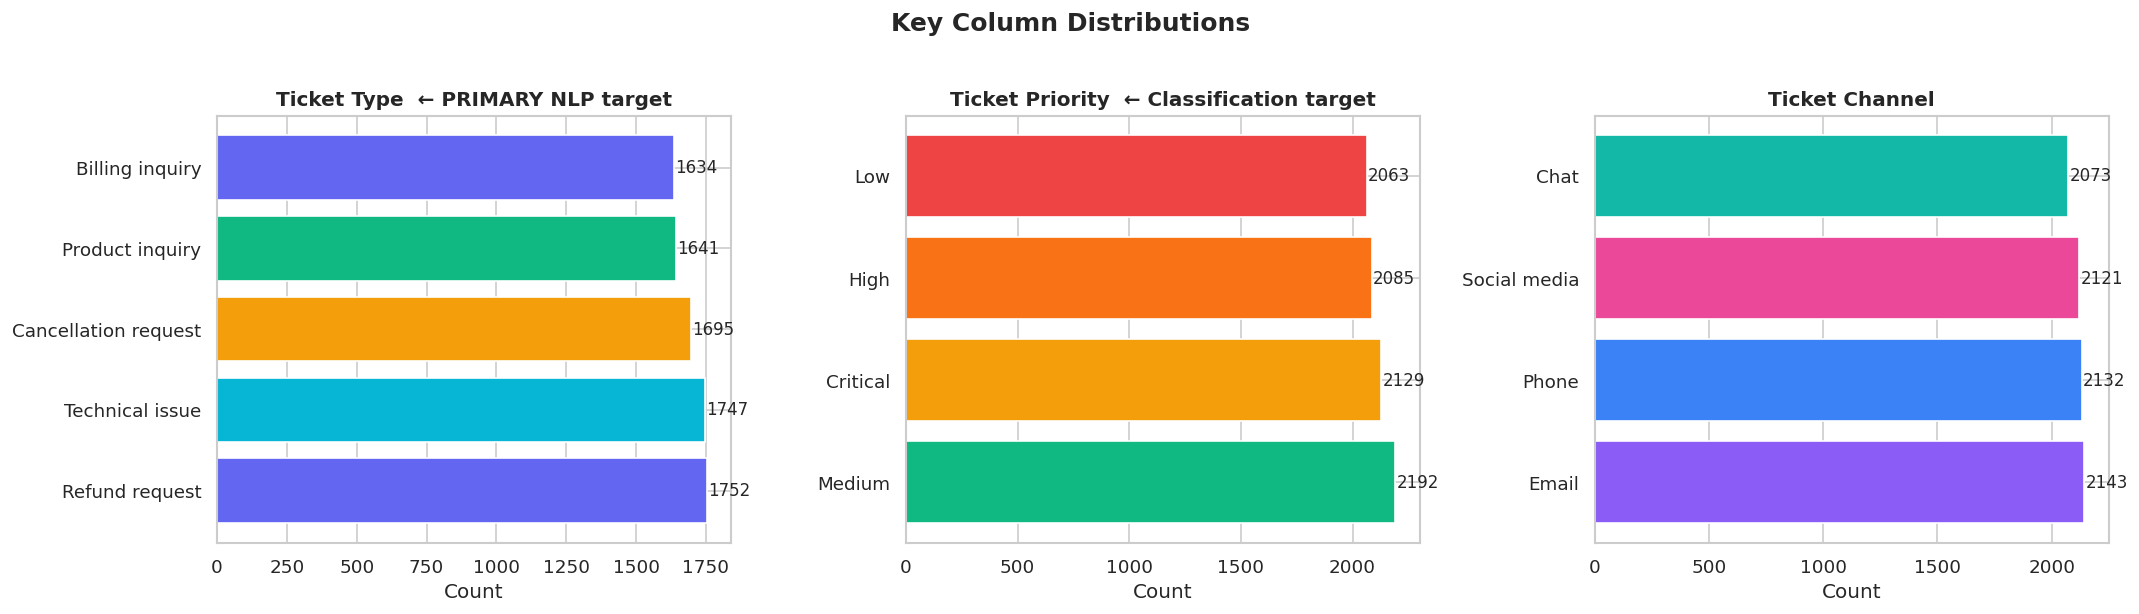

Saved!


In [19]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ticket Type
tc = df['ticket_type'].value_counts()
axes[0].barh(tc.index, tc.values,
             color=['#6366f1','#06b6d4','#f59e0b','#10b981'])
axes[0].set_title('Ticket Type  ← PRIMARY NLP target', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(tc.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Ticket Priority
pc = df['ticket_priority'].value_counts()
axes[1].barh(pc.index, pc.values,
             color=['#10b981','#f59e0b','#f97316','#ef4444'])
axes[1].set_title('Ticket Priority  ← Classification target', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(pc.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=10)

# Ticket Channel
cc = df['ticket_channel'].value_counts()
axes[2].barh(cc.index, cc.values,
             color=['#8b5cf6','#3b82f6','#ec4899','#14b8a6'])
axes[2].set_title('Ticket Channel', fontweight='bold')
axes[2].set_xlabel('Count')
for i, v in enumerate(cc.values):
    axes[2].text(v + 5, i, str(v), va='center', fontsize=10)

plt.suptitle('Key Column Distributions', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [20]:
# Class imbalance check
print("=" * 55)
print("CLASS BALANCE ANALYSIS")
print("=" * 55)

for col in ['ticket_type', 'ticket_priority']:
    counts = df[col].value_counts()
    pct    = df[col].value_counts(normalize=True) * 100
    print(f"\n--- {col} ---")
    for label in counts.index:
        bar = '█' * int(pct[label] / 2)
        print(f"  {label:<28} {counts[label]:>5}  ({pct[label]:.1f}%)  {bar}")

    ratio = counts.max() / counts.min()
    print(f"\n  Imbalance ratio: {ratio:.2f}x")
    if ratio > 2:
        print("  ⚠ Imbalance detected — will use class_weight='balanced'")
    else:
        print("  ✓ Fairly balanced")

CLASS BALANCE ANALYSIS

--- ticket_type ---
  Refund request                1752  (20.7%)  ██████████
  Technical issue               1747  (20.6%)  ██████████
  Cancellation request          1695  (20.0%)  ██████████
  Product inquiry               1641  (19.4%)  █████████
  Billing inquiry               1634  (19.3%)  █████████

  Imbalance ratio: 1.07x
  ✓ Fairly balanced

--- ticket_priority ---
  Medium                        2192  (25.9%)  ████████████
  Critical                      2129  (25.1%)  ████████████
  High                          2085  (24.6%)  ████████████
  Low                           2063  (24.4%)  ████████████

  Imbalance ratio: 1.06x
  ✓ Fairly balanced


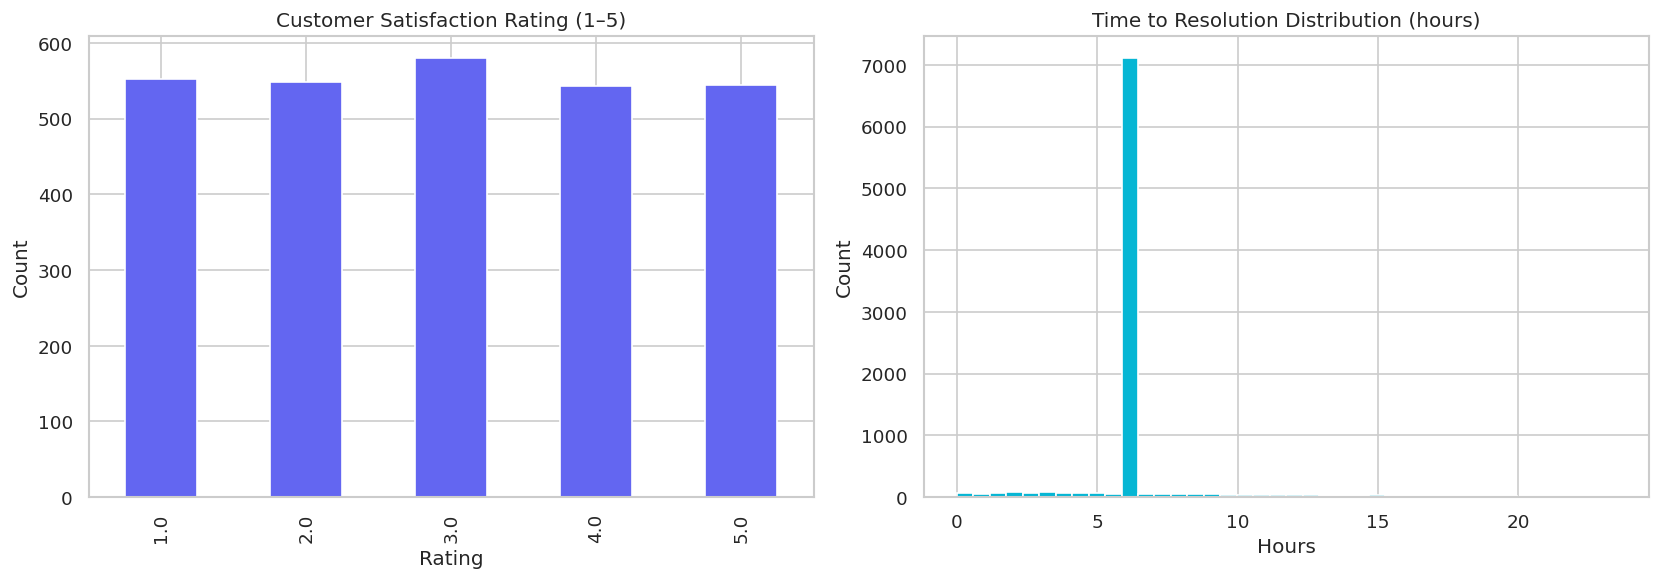

Avg resolution time: 6.55 hours
Median resolution time: 6.34 hours


In [21]:
# Cell 5 — Satisfaction rating distribution

# Ensure both relevant columns are datetime objects
df['first_response_time'] = pd.to_datetime(df['first_response_time'], errors='coerce')
df['time_to_resolution']  = pd.to_datetime(df['time_to_resolution'], errors='coerce')

# Calculate the duration in hours
df['resolution_duration_hours'] = (df['time_to_resolution'] - df['first_response_time']).dt.total_seconds() / 3600

# Replace negative resolution durations with NaN as they are illogical
df.loc[df['resolution_duration_hours'] < 0, 'resolution_duration_hours'] = pd.NA

# Impute missing values in 'resolution_duration_hours' with the median
median_resolution_duration = df['resolution_duration_hours'].median()
df['resolution_duration_hours'].fillna(median_resolution_duration, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction histogram
df['customer_satisfaction_rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#6366f1', edgecolor='white'
)
axes[0].set_title('Customer Satisfaction Rating (1–5)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Time to Resolution distribution
axes[1].hist(df['resolution_duration_hours'], bins=40, color='#06b6d4', edgecolor='white')
axes[1].set_title('Time to Resolution Distribution (hours)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Avg resolution time:", round(df['resolution_duration_hours'].mean(), 2), "hours")
print("Median resolution time:", round(df['resolution_duration_hours'].median(), 2), "hours")

In [22]:
df.shape

(8469, 18)

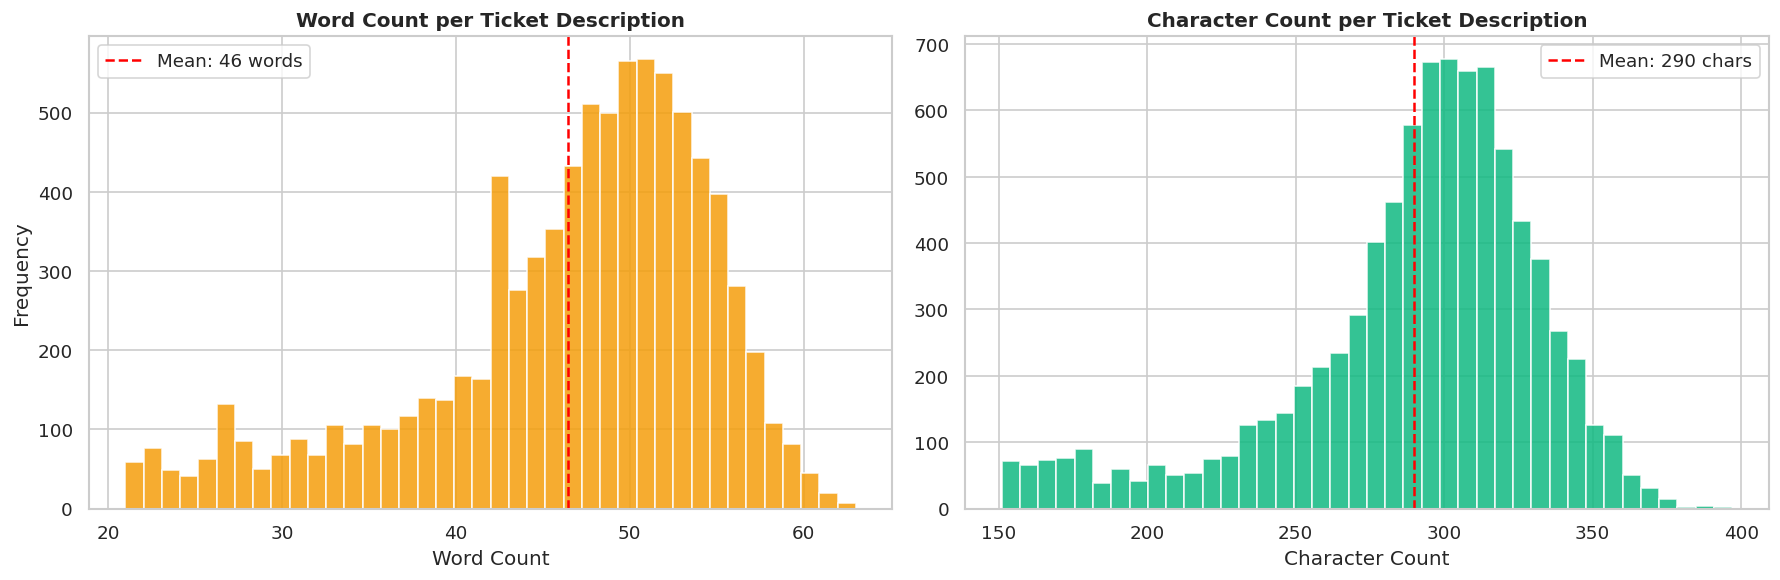

Avg words : 46.5
Avg chars : 289.8
Max words : 63


In [23]:
# Text length analysis
# Compute text features
df['word_count'] = df['ticket_description'].fillna('').apply(lambda x: len(str(x).split()))
df['char_count'] = df['ticket_description'].fillna('').apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['word_count'], bins=40,
             color='#f59e0b', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['word_count'].mean():.0f} words")
axes[0].set_title('Word Count per Ticket Description', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['char_count'], bins=40,
             color='#10b981', edgecolor='white', alpha=0.85)
axes[1].axvline(df['char_count'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['char_count'].mean():.0f} chars")
axes[1].set_title('Character Count per Ticket Description', fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR + 'text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg words : {df['word_count'].mean():.1f}")
print(f"Avg chars : {df['char_count'].mean():.1f}")
print(f"Max words : {df['word_count'].max()}")

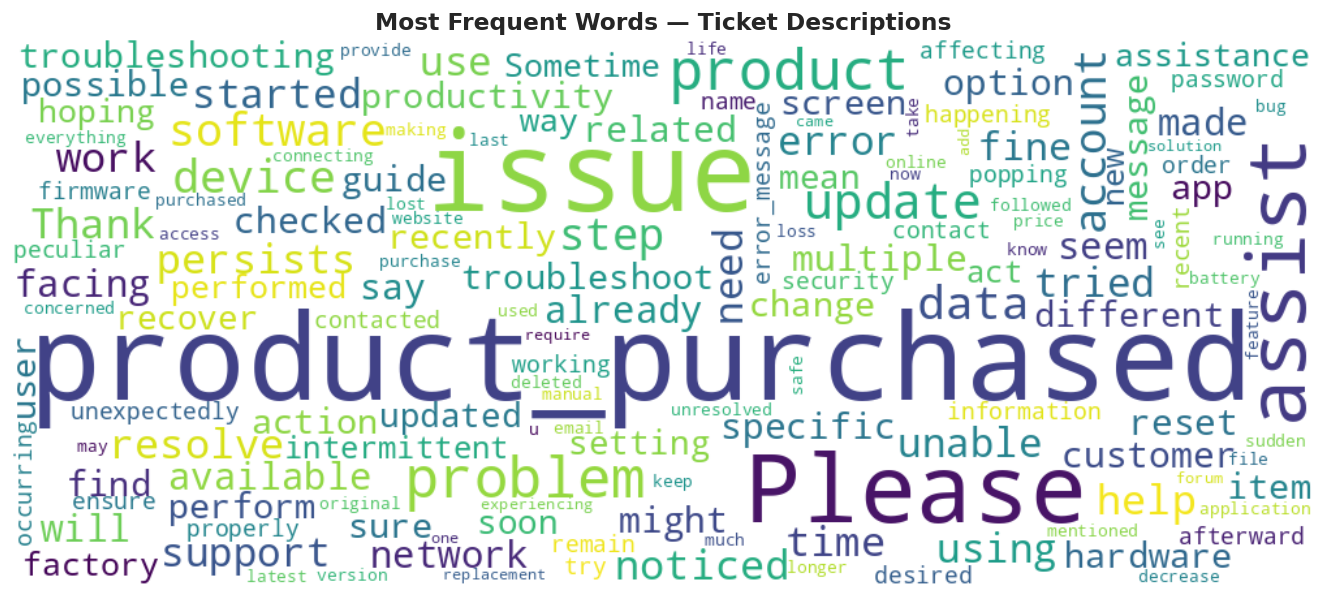

Saved!


In [24]:
# Word cloud
# Run this first if wordcloud not installed:
# !pip install wordcloud -q

from wordcloud import WordCloud

text = ' '.join(df['ticket_description'].fillna('').astype(str).values)

wc = WordCloud(
    width=1000, height=420,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False
).generate(text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words — Ticket Descriptions',
          fontsize=14, fontweight='bold')
plt.savefig(PLOTS_DIR + 'wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

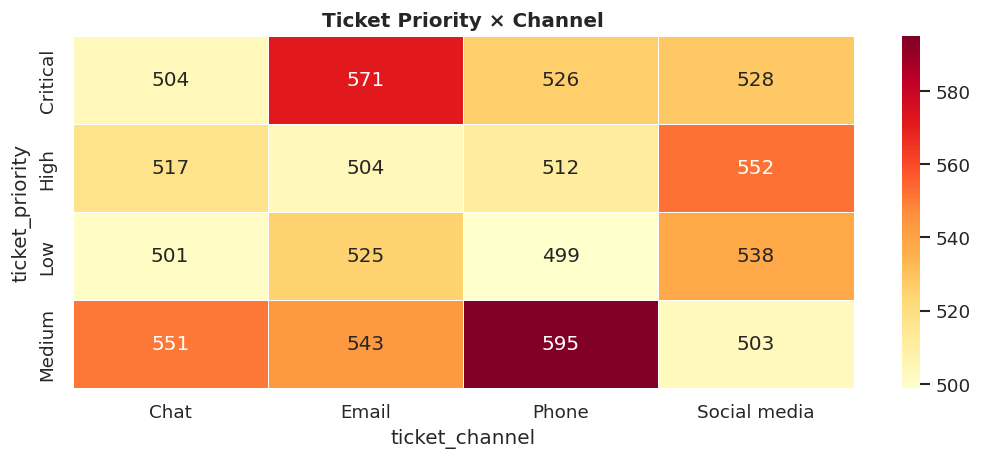

In [25]:
# Heatmap
cross = pd.crosstab(df['ticket_priority'], df['ticket_channel'])

plt.figure(figsize=(9, 4))
sns.heatmap(cross, annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5, linecolor='white')
plt.title('Ticket Priority × Channel', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'priority_channel_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

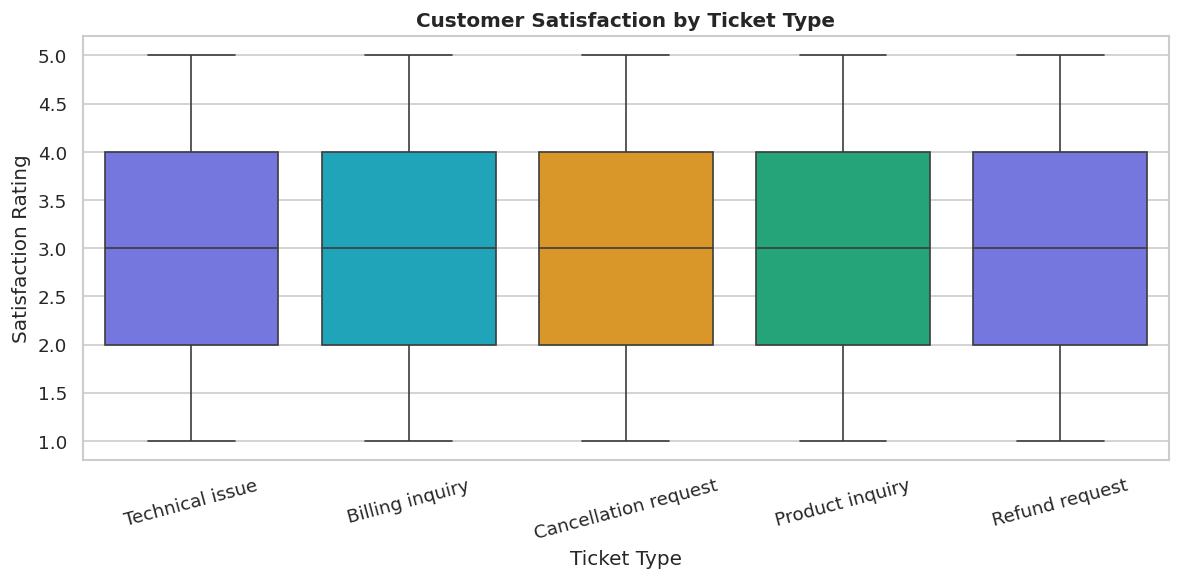

In [26]:
# Satisfaction by imagetype
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='ticket_type',
    y='customer_satisfaction_rating',
    palette=['#6366f1','#06b6d4','#f59e0b','#10b981']
)
plt.title('Customer Satisfaction by Ticket Type', fontweight='bold')
plt.xlabel('Ticket Type')
plt.ylabel('Satisfaction Rating')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'satisfaction_by_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

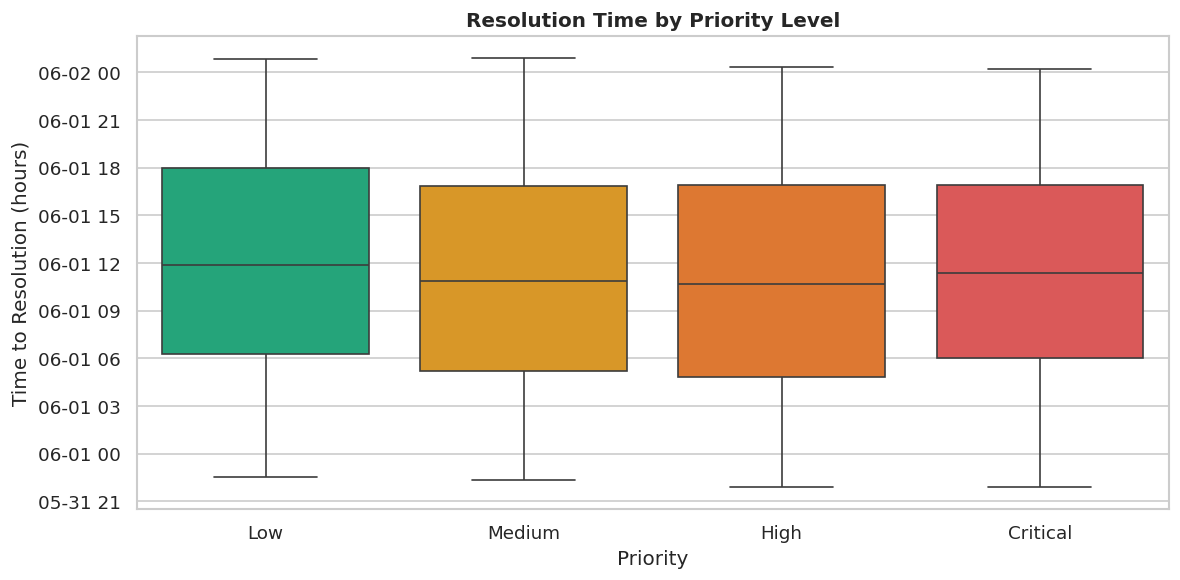

In [27]:
# Resolution time by priority
plt.figure(figsize=(10, 5))
order = ['Low', 'Medium', 'High', 'Critical']

# Only keep valid priority values for ordering
valid_order = [o for o in order if o in df['ticket_priority'].unique()]

sns.boxplot(
    data=df,
    x='ticket_priority',
    y='time_to_resolution',
    order=valid_order,
    palette=['#10b981','#f59e0b','#f97316','#ef4444']
)
plt.title('Resolution Time by Priority Level', fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Time to Resolution (hours)')
plt.tight_layout()
plt.savefig(PLOTS_DIR + 'resolution_by_priority.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print("=" * 55)
print("EDA COMPLETE — SUMMARY")
print("=" * 55)
print(f"Total tickets          : {len(df):,}")
print(f"Ticket types           : {df['ticket_type'].nunique()} classes")
print(f"Priority levels        : {df['ticket_priority'].nunique()} classes")
print(f"Channels               : {df['ticket_channel'].nunique()}")
print(f"Avg satisfaction       : {df['customer_satisfaction_rating'].mean():.2f} / 5")
print(f"Avg resolution time    : {df['time_to_resolution'].mean():.1f} hours")
print(f"Avg words/description  : {df['word_count'].mean():.0f}")
print(f"\nPlots saved to        : {PLOTS_DIR}")
print("\nNext step → Day 5-6: Text Preprocessing Pipeline")

EDA COMPLETE — SUMMARY
Total tickets          : 8,469
Ticket types           : 5 classes
Priority levels        : 4 classes
Channels               : 4
Avg satisfaction       : 2.99 / 5
Avg resolution time    : .1f hours
Avg words/description  : 46

Plots saved to        : /content/drive/MyDrive/final_project/plots/

Next step → Day 5-6: Text Preprocessing Pipeline


In [29]:
df.to_csv('/content/drive/MyDrive/final_project/df_clean_base.csv', index=False)
